In [1]:
from pathlib import Path

from config import RESULTS_DIR
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

In [2]:
from core.dgp import DGP_EXAMPLES, ARGARCHProcess


DGP_EXAMPLES["ar_garch"]=lambda: ARGARCHProcess().calibrate_params(mu=0.15, sigma=0.3)


In [3]:
# name : (dgp_names, model_short_names)
scenarios = {
    "tails_hac": (
        ["iid_t6"],
        ["iid_student_t", "hac"],
    ),
    "skew_hac": (
        ["iid_skewt60_m05", "iid_skewt6_m05"],
        ["iid_nonnormal", "hac"],
    ),
    "non4_hac": (
        ["iid_t3"],
        ["iid_student_t", "hac"],
    ),
    "serial_hac": (
        ["ar1_06_normal", "ar1_m06_normal"],
        ["ar1_normal", "hac"],
    ),
    "hetero_tails_hac": (
        ["garch_normal"],
        ["garch11", "hac"],
    ),
    "efficiency_hac": (
        ["iid_normal"],
        ["iid_normal", "hac"],
    ),
    "serial_hetero_hac": (
        ["ar_garch"],
        ["ar1_nonnormal", "hac"],
    ),
}

parameters = {
    "n_sim": [1_000, 10_000, 30_000],
    "T":     [100, 500, 2_000],
}

In [4]:
N_SIM  = 30_000
N_JOBS = 8
param_name = "T"
param_values = parameters[param_name]

experiments = {
    "tails_hac": ExperimentSpec(
        scenario   = scenarios["tails_hac"],
        param_name = param_name,
        param_values = param_values,
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
    "skew_hac": ExperimentSpec(
        scenario   = scenarios["skew_hac"],
        param_name = param_name,
        param_values = param_values,
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
    "non4_hac": ExperimentSpec(
        scenario   = scenarios["non4_hac"],
        param_name = param_name,
        param_values = param_values,
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
    "serial_hac": ExperimentSpec(
        scenario   = scenarios["serial_hac"],
        param_name = param_name,
        param_values = param_values,
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
    "hetero_tails_hac": ExperimentSpec(
        scenario   = scenarios["hetero_tails_hac"],
        param_name = param_name,
        param_values = param_values,
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM,
        th_moments = True,
        n_jobs = N_JOBS,
    ),
    "efficiency_hac": ExperimentSpec(
        scenario   = scenarios["efficiency_hac"],
        param_name = param_name,
        param_values = param_values,
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
    "serial_hetero_hac": ExperimentSpec(
        scenario   = scenarios["serial_hetero_hac"],
        param_name = param_name,
        param_values = param_values,
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
}

In [ ]:
run_selected_configs(
    experiments,
    selected_experiments=[
        "tails_hac",
        "skew_hac",
        "non4_hac",
        "serial_hac",
        "hetero_tails_hac",
        "efficiency_hac",
        "serial_hetero_hac",
    ],
)

In [7]:
#common
line_plot_kargs = dict(reverse=False, 
                       linewidth=1,
                       log=True, yticks=[0.92, 0.93, 0.94, 0.95, 0.96, 0.97],
                       xticks=param_values)

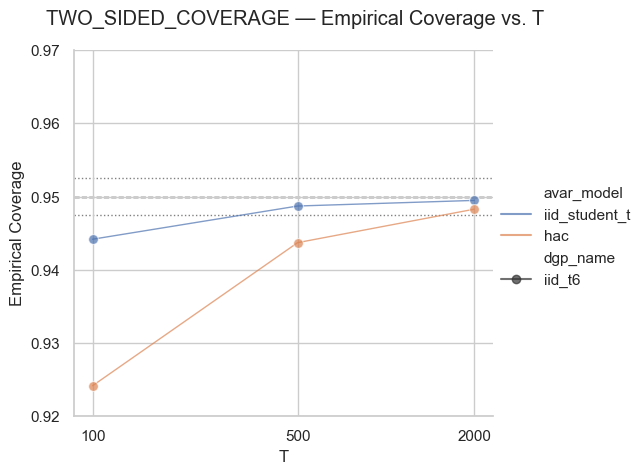

In [9]:
run_analysis(experiments, "tails_hac", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder= RESULTS_DIR / "hac",
             line_plot_kargs=line_plot_kargs)

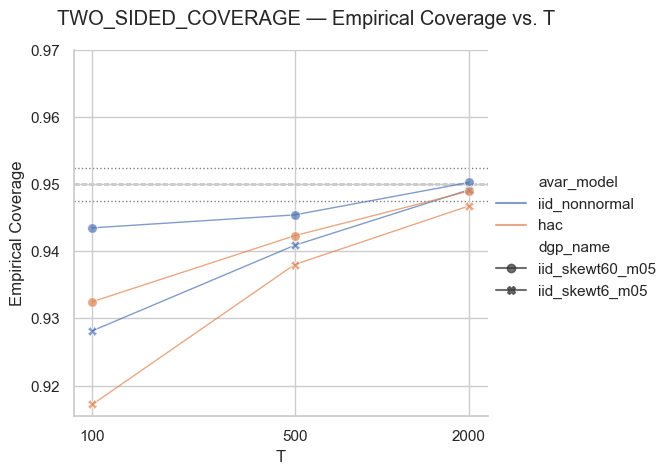

In [10]:
run_analysis(experiments, "skew_hac", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder= RESULTS_DIR / "hac",
             line_plot_kargs=line_plot_kargs | 
             dict(markers=['o', 'X']))

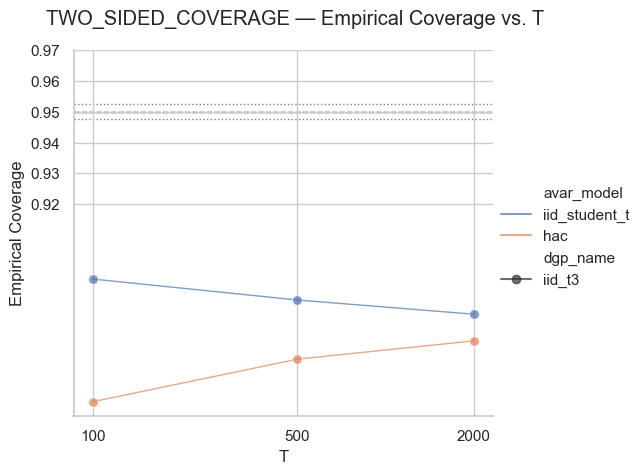

In [11]:
run_analysis(experiments, "non4_hac", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder= RESULTS_DIR / "hac",
             line_plot_kargs=line_plot_kargs)

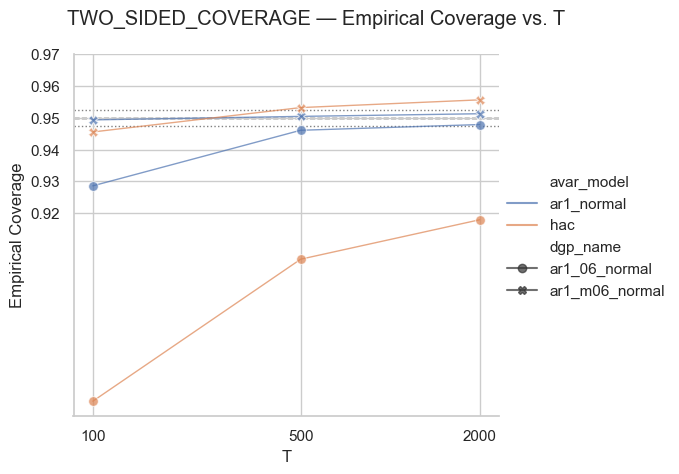

In [12]:
run_analysis(experiments, "serial_hac", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder= RESULTS_DIR / "hac",
             line_plot_kargs=line_plot_kargs | 
             dict(markers=['o', 'X']))

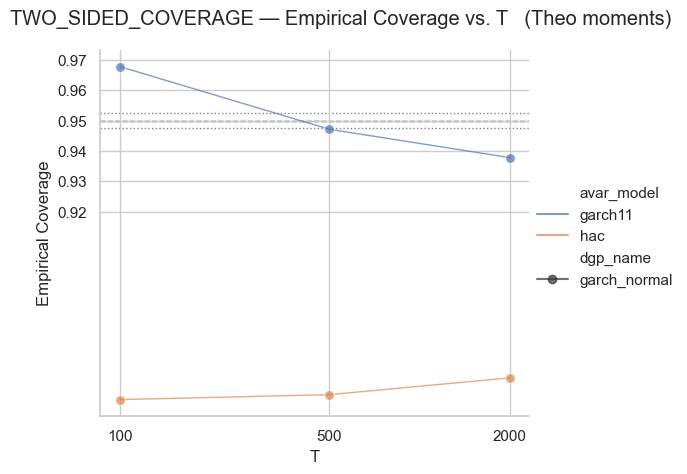

In [13]:
run_analysis(experiments, "hetero_tails_hac", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder= RESULTS_DIR / "hac",
             line_plot_kargs=line_plot_kargs)

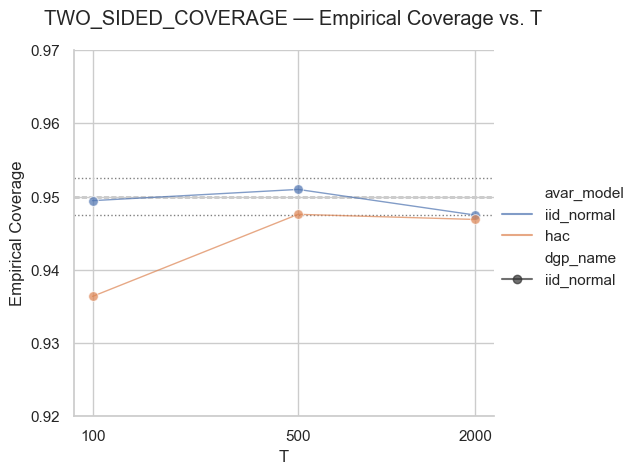

In [14]:
run_analysis(experiments, "efficiency_hac", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder= RESULTS_DIR / "hac",
             line_plot_kargs=line_plot_kargs)

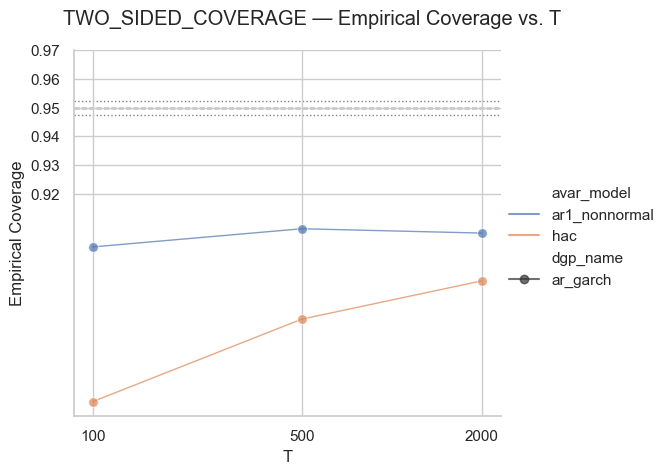

In [15]:
run_analysis(experiments, "serial_hetero_hac", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder= RESULTS_DIR / "hac",
             line_plot_kargs=line_plot_kargs)